# **Sambungin ke drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Import Libraries**

In [ ]:
!pip install ultralytics --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import os
import cv2
import shutil
from pathlib import Path
import random
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

train_img = len(os.listdir("/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/train/images"))
train_lbl = len(os.listdir("/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/train/labels"))

valid_img = len(os.listdir("/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images"))
valid_lbl = len(os.listdir("/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/labels"))

print("Train Images :", train_img)
print("Train Labels :", train_lbl)
print("Valid Images :", valid_img)
print("Valid Labels :", valid_lbl)


Train Images : 2062
Train Labels : 2062
Valid Images : 873
Valid Labels : 873


In [ ]:
label_path = "/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/train/labels"

with open(os.path.join(label_path, os.listdir(label_path)[0])) as f:
    print(f.read())


1 0.49 0.5241666666666667 0.8466666666666667 0.6483333333333333


In [ ]:
classes = set()

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file)) as f:
        for line in f:
            classes.add(int(line.split()[0]))

print("Class ID ditemukan:", classes)


Class ID ditemukan: {0, 1, 2, 3, 4, 5}


In [ ]:
data_yaml = """
path: /content/drive/MyDrive/Data_Mobil_Bus_Motorbike

train: train/images
val: valid/images

nc: 3
names: ['car', 'bus', 'motorbike']
"""

with open("/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/data.yaml", "w") as f:
    f.write(data_yaml)

print("✅ data.yaml berhasil dibuat")


✅ data.yaml berhasil dibuat


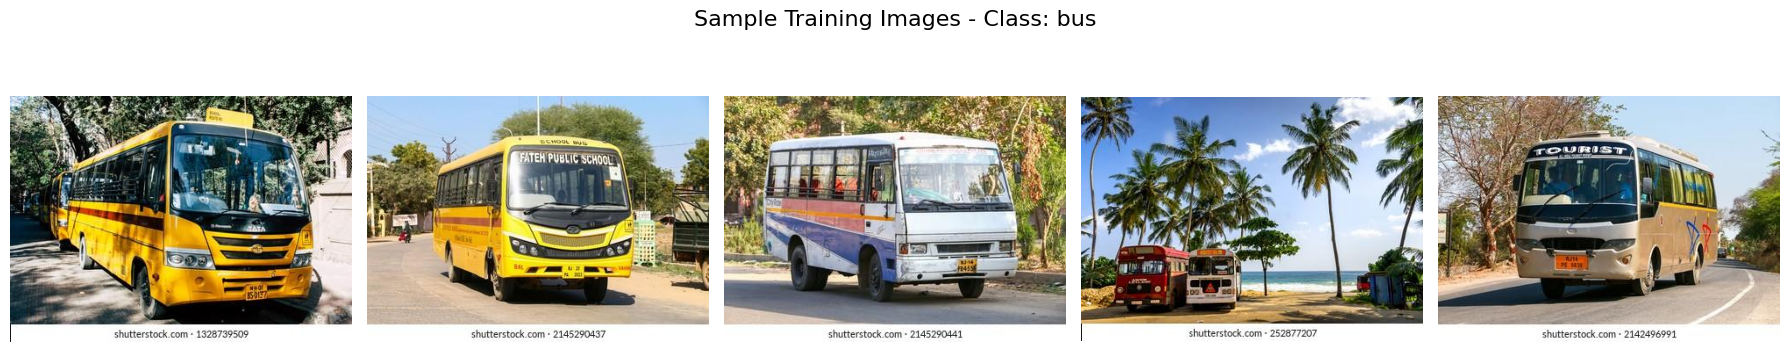

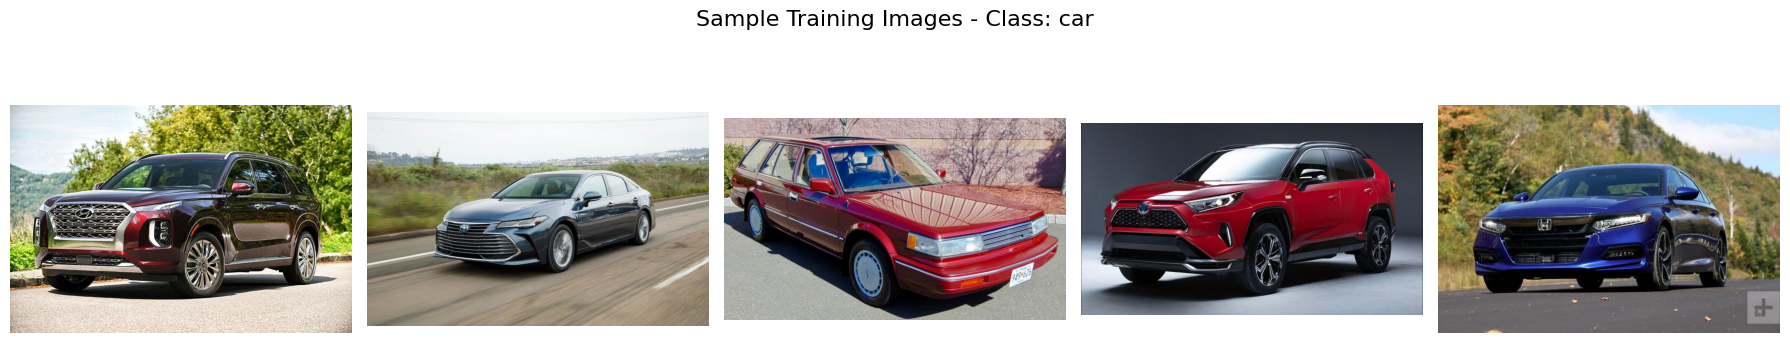

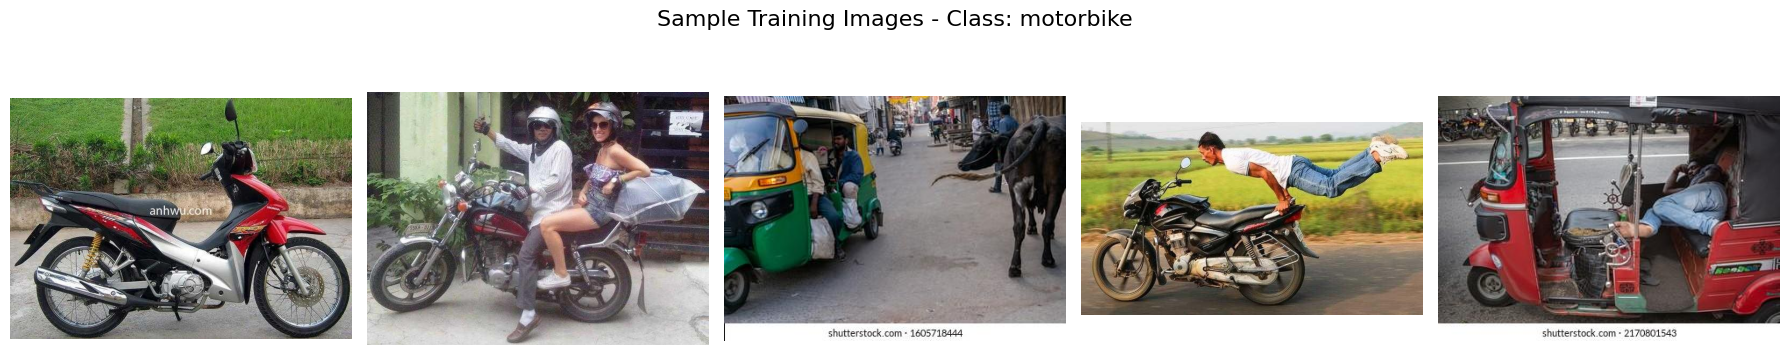

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

# Path dataset
images_dir = "/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/train/images"
labels_dir = "/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/train/labels"

# Mapping class (HANYA 3 CLASS)
class_names = {
    0: "bus",
    1: "car",
    2: "motorbike"
}

MAX_PER_CLASS = 5
samples = defaultdict(list)

# Ambil sample gambar per class
for label_file in os.listdir(labels_dir):
    label_path = os.path.join(labels_dir, label_file)

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        class_id = int(line.split()[0])

        if class_id in class_names and len(samples[class_id]) < MAX_PER_CLASS:
            img_name = label_file.replace(".txt", ".jpg")
            img_path = os.path.join(images_dir, img_name)

            if os.path.exists(img_path) and img_path not in samples[class_id]:
                samples[class_id].append(img_path)

    if all(len(samples[c]) >= MAX_PER_CLASS for c in class_names):
        break

# ===============================
# TAMPILKAN KE SAMPING (GRID)
# ===============================
for class_id in class_names:
    img_paths = samples[class_id]
    if not img_paths:
        continue

    fig, axes = plt.subplots(1, len(img_paths), figsize=(18, 4))
    fig.suptitle(f"Sample Training Images - Class: {class_names[class_id]}", fontsize=16)

    if len(img_paths) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, img_paths):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


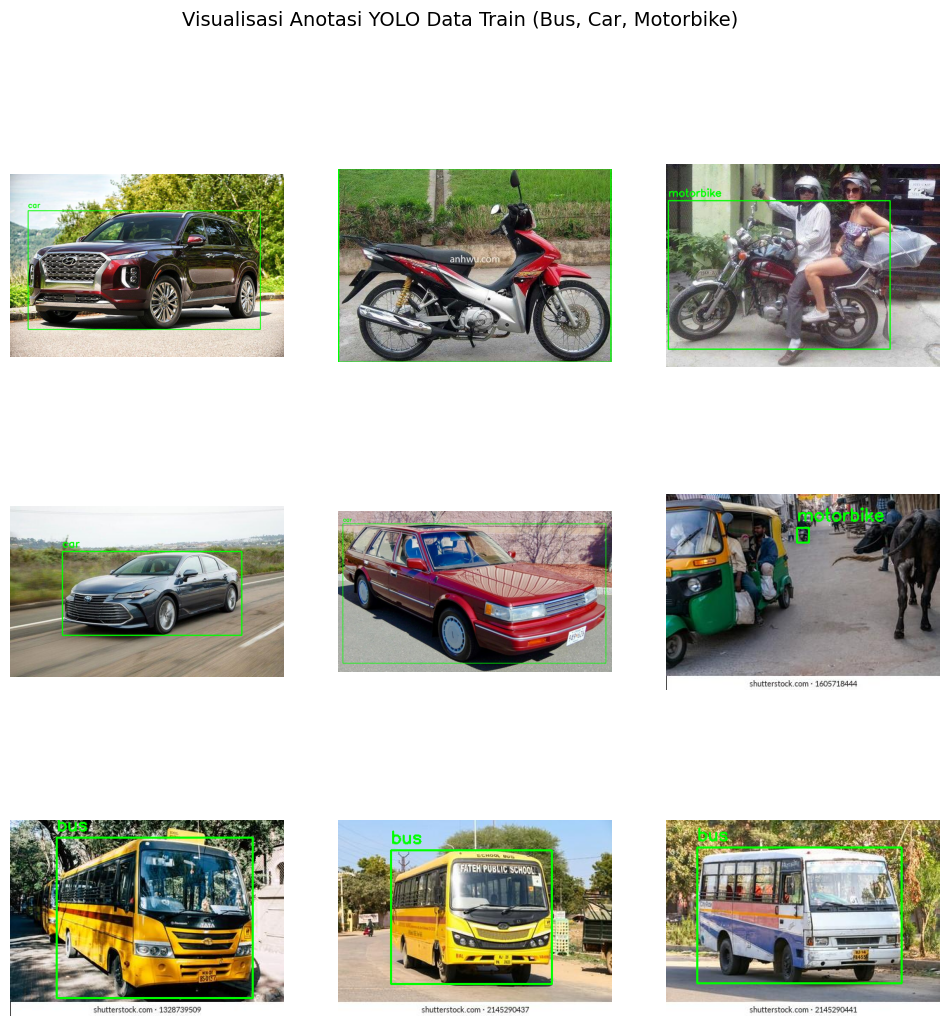

Jumlah gambar per kelas:
bus: 3
car: 3
motorbike: 3


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

images_dir = "/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/train/images"
labels_dir = "/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/train/labels"

class_names = {
    0: "bus",
    1: "car",
    2: "motorbike"
}

MAX_PER_CLASS = 3
collected = {0: 0, 1: 0, 2: 0}

plt.figure(figsize=(12, 12))
shown = 0

for label_file in os.listdir(labels_dir):

    label_path = os.path.join(labels_dir, label_file)
    img_path = os.path.join(images_dir, label_file.replace(".txt", ".jpg"))

    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w, _ = img.shape

    with open(label_path) as f:
        lines = f.readlines()

    used = False

    for line in lines:
        class_id, x, y, bw, bh = map(float, line.split())
        class_id = int(class_id)

        if class_id not in class_names:
            continue

        if collected[class_id] >= MAX_PER_CLASS:
            continue

        # YOLO → pixel
        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img,
            class_names[class_id],
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

        collected[class_id] += 1
        used = True

    if used:
        shown += 1
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(3, 3, shown)
        plt.imshow(img)
        plt.axis("off")

    if sum(collected.values()) >= MAX_PER_CLASS * 3:
        break

plt.suptitle(
    "Visualisasi Anotasi YOLO Data Train (Bus, Car, Motorbike)",
    fontsize=14
)
plt.show()

print("Jumlah gambar per kelas:")
for k, v in collected.items():
    print(f"{class_names[k]}: {v}")


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16
)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c348f603c20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

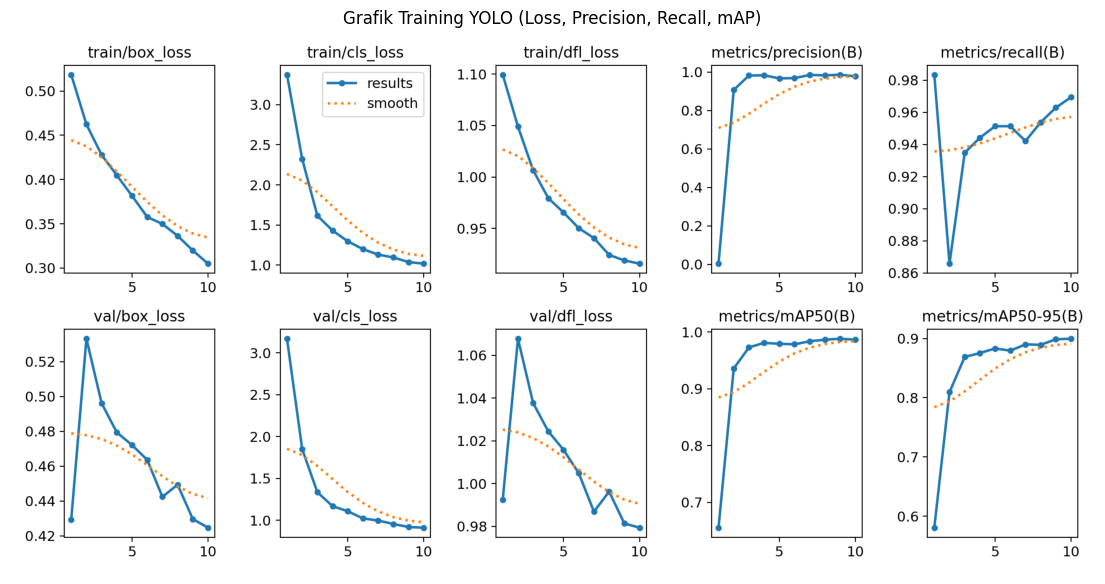

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# Path hasil training YOLO
train_dir = "/content/runs/detect/train2"
results_img = os.path.join(train_dir, "results.png")

# Cek apakah file ada
if not os.path.exists(results_img):
    print("❌ results.png tidak ditemukan. Pastikan training sudah selesai.")
else:
    img = cv2.imread(results_img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Grafik Training YOLO (Loss, Precision, Recall, mAP)")
    plt.show()

In [ ]:
pr_curve = os.path.join(train_dir, "PR_curve.png")

if os.path.exists(pr_curve):
    img = cv2.imread(pr_curve)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Precision–Recall Curve")
    plt.show()


In [ ]:
model.val(
    data="/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/data.yaml"
)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 6.1±4.3 MB/s, size: 43.6 KB)
val: Scanning /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/labels.cache... 873 images, 0 backgrounds, 417 corrupt: 100% ━━━━━━━━━━━━ 873/873 215.4Mit/s 0.0s
val: /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/01000_GMC-Savana-Van-2012_jpg.rf.c7f77201d408dd94fef8aedbc139eb63.jpg: ignoring corrupt image/label: Label class 5 exceeds dataset class count 3. Possible class labels are 0-2
val: /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/02358_Nissan-NV-Passenger-Van-2012_jpg.rf.c735f551213e325c70b7e97c70c61950.jpg: ignoring corrupt image/label: Label class 5 exceeds dataset class count 3. Possible class labels are 0-2
val: /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/02564_Chevrolet-Express-Van-2007_jpg.rf.4623eb

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c349bfabbf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
from ultralytics import YOLO

# Load model hasil training TERBARU
model = YOLO("/content/runs/detect/train2/weights/best.pt")

# Inference ke data valid
results = model(
    "/content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images",
    conf=0.3
)




image 1/873 /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/00110_jpg.rf.2ac8409fe9448d6c48dd3040cd16d7c9.jpg: 480x640 1 bus, 246.5ms
image 2/873 /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/00262_jpg.rf.c26493a7e52b024104750a195b2782c5.jpg: 480x640 1 bus, 205.2ms
image 3/873 /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/00790_jpg.rf.5c1c6cd19d5f772716612c9d0ad57b75.jpg: 416x640 1 bus, 209.7ms
image 4/873 /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/00826_jpg.rf.06635a83496392e6f215607b7ff2134e.jpg: 448x640 1 bus, 186.4ms
image 5/873 /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/01000_GMC-Savana-Van-2012_jpg.rf.c7f77201d408dd94fef8aedbc139eb63.jpg: 480x640 1 bus, 165.0ms
image 6/873 /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/01444_jpg.rf.c2f707e7a1c5829d9ca91ae4c8d1d203.jpg: 416x640 1 bus, 140.5ms
image 7/873 /content/drive/MyDrive/Data_Mobil_Bus_Motorbike/valid/images/01455_jpg.rf.0fe4fc23e34

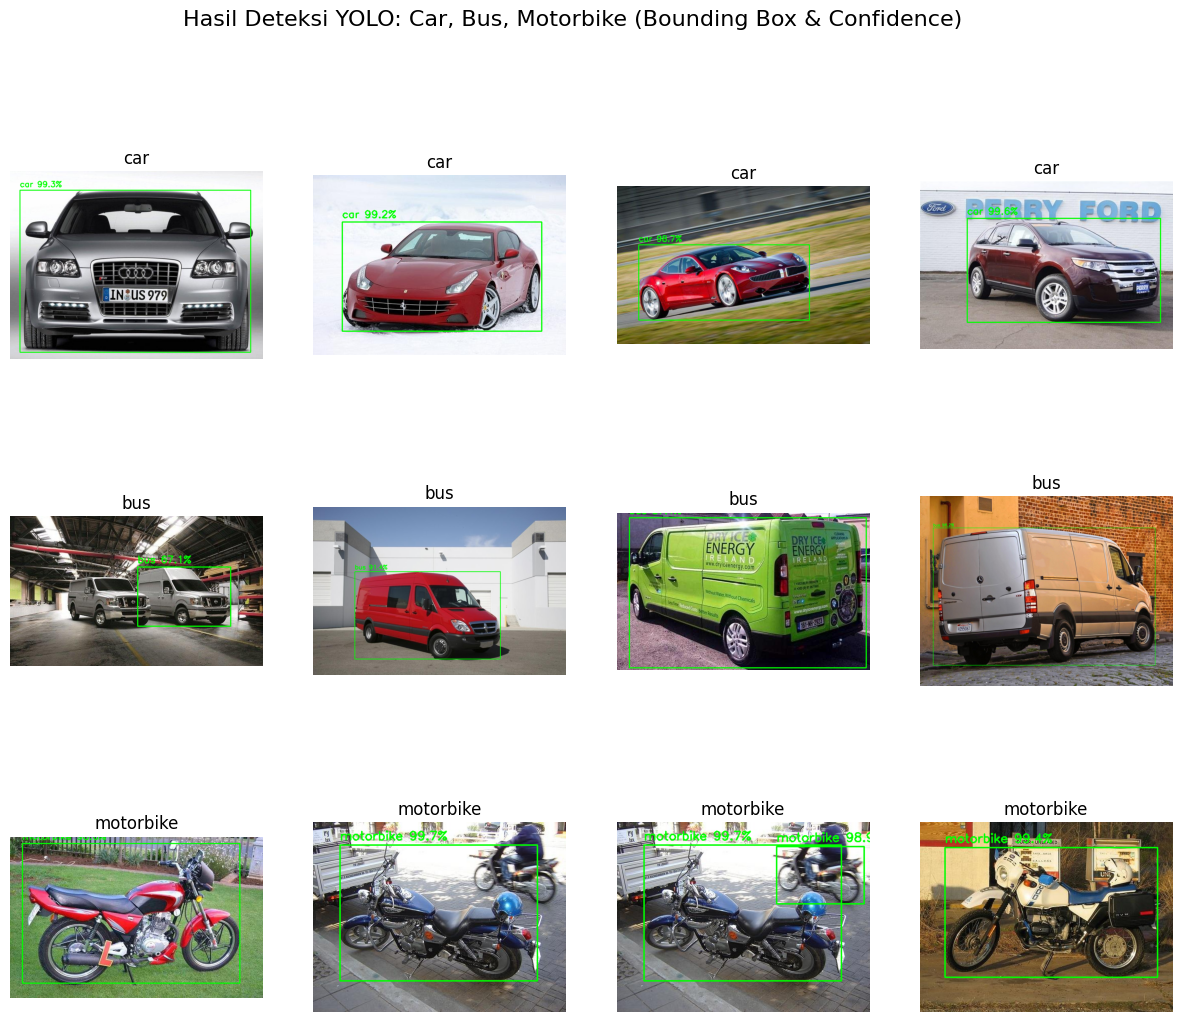

In [ ]:
import cv2
import matplotlib.pyplot as plt

MAX_PER_CLASS = 4   # 3–5 gambar
shown_count = {0:0, 1:0, 2:0}

plt.figure(figsize=(15,12))
plot_idx = 1

for r in results:
    img = r.orig_img.copy()

    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])

        if cls_id not in shown_count:
            continue
        if shown_count[cls_id] >= MAX_PER_CLASS:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Bounding box hijau
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

        label = f"{class_names[cls_id]} {conf*100:.1f}%"
        cv2.putText(
            img, label,
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

        shown_count[cls_id] += 1

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(3,4,plot_idx)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(class_names[cls_id])
        plot_idx += 1

        if plot_idx > 12:
            break

    if plot_idx > 12:
        break

plt.suptitle(
    "Hasil Deteksi YOLO: Car, Bus, Motorbike (Bounding Box & Confidence)",
    fontsize=16
)
plt.show()
